# 招聘数据分析

这个 Notebook 通过 `src/analysis_api.py` 完成分析，保证后续前端可以复用同一套接口。

In [14]:
from pathlib import Path
from pprint import pprint
import importlib
import sys

ROOT = Path.cwd().resolve().parent
if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))

import analysis_api
importlib.reload(analysis_api)
from analysis_api import get_analysis_payload

In [6]:
data_dir = ROOT / "data"
output_dir = ROOT / "data" / "analysis"

payload = get_analysis_payload(
    data_dir=data_dir,
    output_dir=output_dir,
    top_n=15,
)

report = payload["report"]
artifacts = payload.get("artifacts", {})

print("总岗位数:", report["meta"]["total_jobs"])
print("数据文件:", report["meta"]["files"])
print("输出目录:", output_dir)

总岗位数: 3613
数据文件: ['antgroup_jobs.csv', 'bytedance_jobs.csv', 'kurogame_jobs.csv', 'netease_jobs.csv', 'tencent_jobs.csv']
输出目录: D:\ayohi\job_info_collector\data\analysis


In [3]:
print("=== 公司分布 Top 10 ===")
pprint(report["overview"]["by_company"][:10])

print("\n=== 城市分布 Top 10 ===")
pprint(report["overview"]["by_work_city"][:10])

print("\n=== 岗位类别 Top 10 ===")
pprint(report["overview"]["by_job_category"][:10])

=== 公司分布 Top 10 ===
[{'count': 2992, 'name': '字节跳动'},
 {'count': 390, 'name': '腾讯'},
 {'count': 90, 'name': '阿里巴巴(蚂蚁集团)'},
 {'count': 81, 'name': '库洛游戏'},
 {'count': 60, 'name': '网易互娱'}]

=== 城市分布 Top 10 ===
[{'count': 1286, 'name': '北京'},
 {'count': 906, 'name': '上海'},
 {'count': 417, 'name': '杭州'},
 {'count': 351, 'name': '深圳'},
 {'count': 263, 'name': '深圳总部'},
 {'count': 176, 'name': '广州'},
 {'count': 48, 'name': '成都'},
 {'count': 36, 'name': 'Singapore-CapitaSky'},
 {'count': 11, 'name': '西安'},
 {'count': 11, 'name': 'Japan-Tokyo-Business'}]

=== 岗位类别 Top 10 ===
[{'count': 528, 'name': '后端'},
 {'count': 478, 'name': '算法'},
 {'count': 386, 'name': '运营'},
 {'count': 281, 'name': '产品'},
 {'count': 214, 'name': '客户端'},
 {'count': 201, 'name': '前端'},
 {'count': 194, 'name': '产品经理'},
 {'count': 192, 'name': '技术'},
 {'count': 97, 'name': '测试'},
 {'count': 97, 'name': '设计'}]


In [ ]:
print("=== 数据质量（缺失率）===")
pprint(report["quality"]["missing_rate"])

print("\n=== 重复情况 ===")
pprint(report["quality"]["duplicates"])

In [ ]:
print("=== 技能关键词 Top 20 ===")
pprint(report["skills"]["keyword_hits"][:20])

print("\n=== 英文技术词 Top 20 ===")
pprint(report["skills"]["top_english_tokens"][:20])

In [ ]:
print("已导出文件:")
pprint(artifacts)

## 高级分析：机器学习与NLP

下面基于 `analysis_api.get_analysis_payload(..., include_advanced=True)` 执行更深入的分析，包括：
- TF-IDF 向量化
- KMeans 职位文本聚类
- NMF 主题抽取
- TruncatedSVD 二维降维可视化

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager

available_fonts = {f.name for f in font_manager.fontManager.ttflist}
preferred_fonts = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Arial Unicode MS", "DejaVu Sans"]
selected_fonts = [f for f in preferred_fonts if f in available_fonts] or ["DejaVu Sans"]

plt.rcParams["font.sans-serif"] = selected_fonts
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="ticks", palette="Set2", context="talk")

payload_adv = get_analysis_payload(
    data_dir=data_dir,
    output_dir=output_dir,
    top_n=20,
    include_advanced=True,
    advanced_options={
        "n_clusters": 10,
        "n_topics": 10,
        "max_features": 6000,
        "min_df": 3,
    },
)

report_adv = payload_adv["report"]
adv = report_adv["advanced_ml_nlp"]
print("Advanced meta:")
pprint(adv["meta"])
print("Font fallback chain:", selected_fonts)


Advanced meta:
{'cluster_count': 10,
 'explained_variance_2d': 0.039101,
 'sample_size': 3613,
 'topic_count': 10,
 'vector_features': 5235}
Font fallback chain: ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']


,cluster_name,size,top_terms
0,运营::运营,867,"[运营, 数据, 策略, 电商, 用户, 业务, 数据分析, 分析, 内容, 行业, 抖音,..."
1,后端::测试,494,"[测试, java, go, c++, python, 参与, 安全, golang, 计算..."
2,算法::模型,492,"[模型, 算法, 模态, 训练, llm, nlp, agent, 生成, pytorch,..."
3,技术::招聘,417,"[招聘, intern, research, 协助, 市场, 管理, 数据中心, devel..."
4,后端::ai,372,"[ai, agent, 模型, 应用, llm, 设计, 数据, 参与, 具备, aigc,..."
5,设计::游戏,270,"[游戏, 设计, 美术, 制作, 玩家, unity, 引擎, 特效, 视觉, 策划, 具备..."
6,算法::算法,208,"[算法, 推荐, 机器, 学习, 模型, 用户, 广告, 数据挖掘, 优秀, 优化, nlp..."
7,前端::前端,177,"[前端, css, html, javascript, 前端开发, web, react, ..."
8,客户端::客户端,160,"[客户端, android, 移动, swift, ios, kotlin, java, c..."
9,后端::php,156,"[php, go, java, 逻辑, c++, 参与, 优秀, python, 前瞻, 拆..."


C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\2844726784.py:11: UserWarning: Glyph 36816 (\N{CJK UNIFIED IDEOGRAPH-8FD0}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\2844726784.py:11: UserWarning: Glyph 33829 (\N{CJK UNIFIED IDEOGRAPH-8425}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\2844726784.py:11: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\2844726784.py:11: UserWarning: Glyph 31471 (\N{CJK UNIFIED IDEOGRAPH-7AEF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\2844726784.py:11: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\2844726784.py:11: UserWarning: Glyph 35797 (\

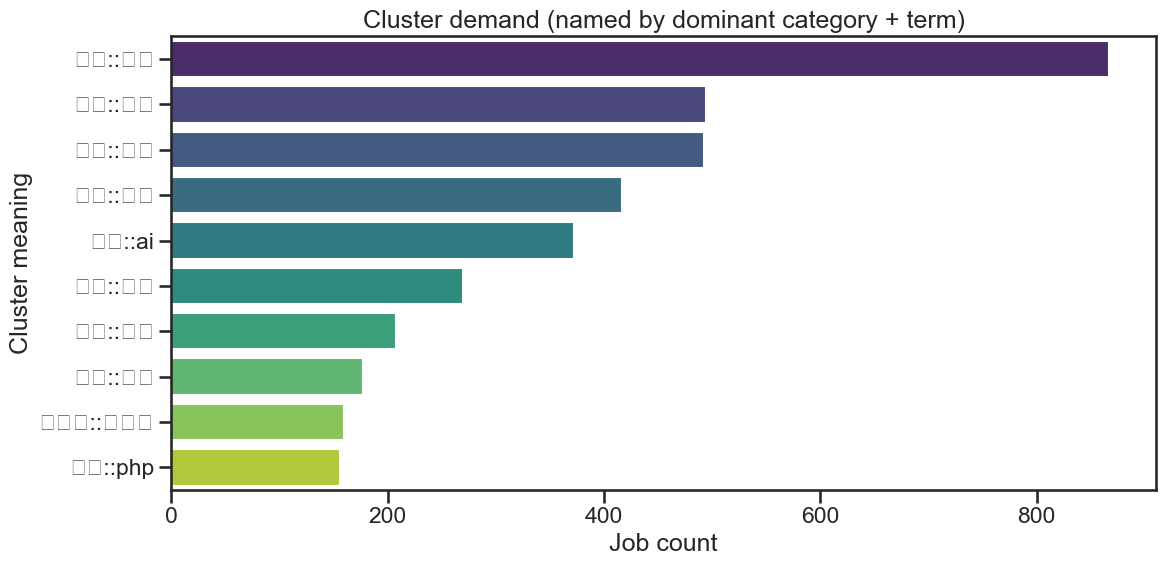

,topic_id,mean_weight,top_terms
0,0,0.018918,"[数据, sql, 数据分析, 业务, 分析, 用户, 策略, 需求, 协助, excel,..."
1,1,0.018240,"[php, go, java, 逻辑, c++, 优秀, 参与, python, 拆分, 前..."
2,2,0.025467,"[ai, agent, 模型, llm, 应用, rag, prompt, 智能, 场景, ..."
3,3,0.029439,"[算法, 模型, 推荐, 学习, 机器, nlp, 模态, llm, 训练, pytorch..."
4,4,0.014258,"[前端, css, web, html, javascript, 前端开发, react, ..."
5,5,0.014695,"[客户端, android, 移动, swift, ios, kotlin, java, c..."
6,6,0.015445,"[游戏, 设计, 美术, 制作, 策划, 玩家, 玩法, 风格, 特效, 视觉, 创意, 角色]"
7,7,0.015460,"[测试, 质量, 保障, 安全, java, 自动化, go, tiktok, python..."
8,8,0.017137,"[mysql, 高效, redis, 认真细致, 以上, 乐观, 中国, 积极, 交易, 编..."
9,9,0.023037,"[运营, 电商, 内容, 行业, 抖音, 商家, 策略, 制定, 用户, 治理, kol, 品类]"


In [16]:
cluster_df = pd.DataFrame(adv["clusters"])
if not cluster_df.empty:
    cluster_df = cluster_df.sort_values("size", ascending=False).reset_index(drop=True)
    display(cluster_df[["cluster_name", "size", "top_terms"]].head(10))

    plt.figure(figsize=(12, 6))
    sns.barplot(data=cluster_df, y="cluster_name", x="size", hue="cluster_name", palette="viridis", legend=False)
    plt.title("Cluster demand (named by dominant category + term)")
    plt.xlabel("Job count")
    plt.ylabel("Cluster meaning")
    plt.tight_layout()
    plt.show()
else:
    print("聚类结果为空，可能是文本数据不足。")


topic_df = pd.DataFrame(adv["topics"])
if not topic_df.empty:
    display(topic_df[["topic_id", "mean_weight", "top_terms"]].head(10))


C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\2741514109.py:28: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\2741514109.py:28: UserWarning: Glyph 31471 (\N{CJK UNIFIED IDEOGRAPH-7AEF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\2741514109.py:28: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\2741514109.py:28: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAPH-8BD5}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\2741514109.py:28: UserWarning: Glyph 35774 (\N{CJK UNIFIED IDEOGRAPH-8BBE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\2741514109.py:28: UserWarning: Glyph 35745 (\

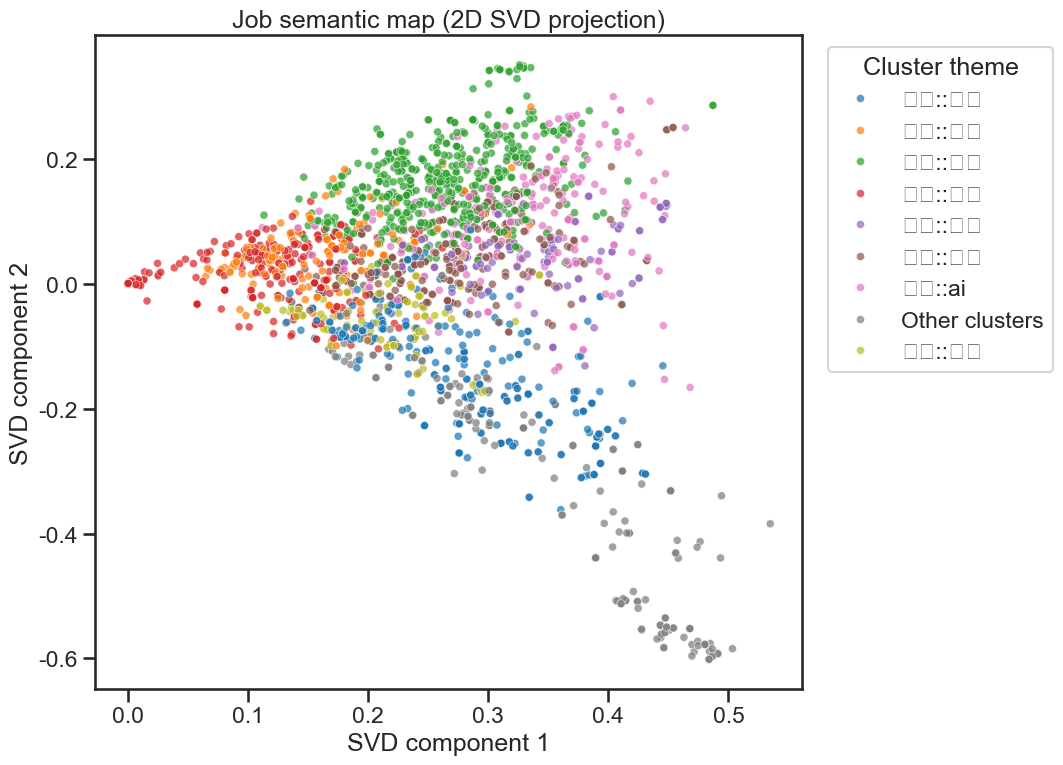

In [17]:
embed_df = pd.DataFrame(adv["embeddings_2d"])
if not embed_df.empty:
    sample_n = min(2200, len(embed_df))
    plot_df = embed_df.sample(sample_n, random_state=42)

    top_clusters = (
        plot_df["cluster_name"].value_counts().head(8).index.tolist()
    )
    plot_df["cluster_group"] = plot_df["cluster_name"].where(
        plot_df["cluster_name"].isin(top_clusters),
        "Other clusters",
    )

    plt.figure(figsize=(11, 8))
    sns.scatterplot(
        data=plot_df,
        x="x",
        y="y",
        hue="cluster_group",
        alpha=0.72,
        s=34,
        palette="tab10",
    )
    plt.title("Job semantic map (2D SVD projection)")
    plt.xlabel("SVD component 1")
    plt.ylabel("SVD component 2")
    plt.legend(title="Cluster theme", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("二维嵌入结果为空。")

C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\1862137261.py:12: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\1862137261.py:12: UserWarning: Glyph 33410 (\N{CJK UNIFIED IDEOGRAPH-8282}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\1862137261.py:12: UserWarning: Glyph 36339 (\N{CJK UNIFIED IDEOGRAPH-8DF3}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\1862137261.py:12: UserWarning: Glyph 21160 (\N{CJK UNIFIED IDEOGRAPH-52A8}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\1862137261.py:12: UserWarning: Glyph 33150 (\N{CJK UNIFIED IDEOGRAPH-817E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\1862137261.py:12: UserWarning: Glyph 35759 (\

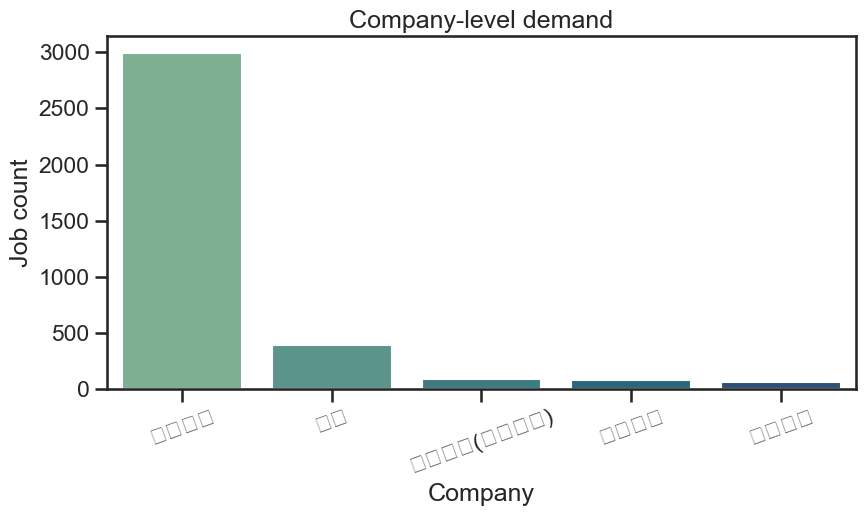

C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\1862137261.py:26: UserWarning: Glyph 36816 (\N{CJK UNIFIED IDEOGRAPH-8FD0}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\1862137261.py:26: UserWarning: Glyph 33829 (\N{CJK UNIFIED IDEOGRAPH-8425}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\1862137261.py:26: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\1862137261.py:26: UserWarning: Glyph 31471 (\N{CJK UNIFIED IDEOGRAPH-7AEF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\1862137261.py:26: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\1862137261.py:26: UserWarning: Glyph 35797 (\

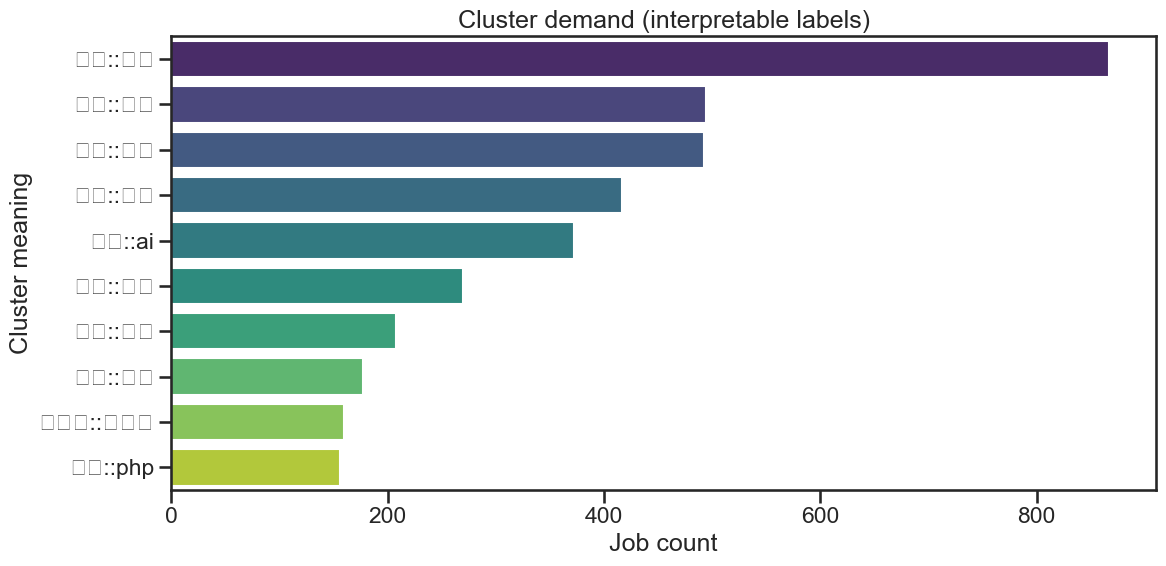

C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\1862137261.py:43: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\1862137261.py:43: UserWarning: Glyph 31471 (\N{CJK UNIFIED IDEOGRAPH-7AEF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\1862137261.py:43: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\1862137261.py:43: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAPH-8BD5}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\1862137261.py:43: UserWarning: Glyph 35774 (\N{CJK UNIFIED IDEOGRAPH-8BBE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\1862137261.py:43: UserWarning: Glyph 35745 (\

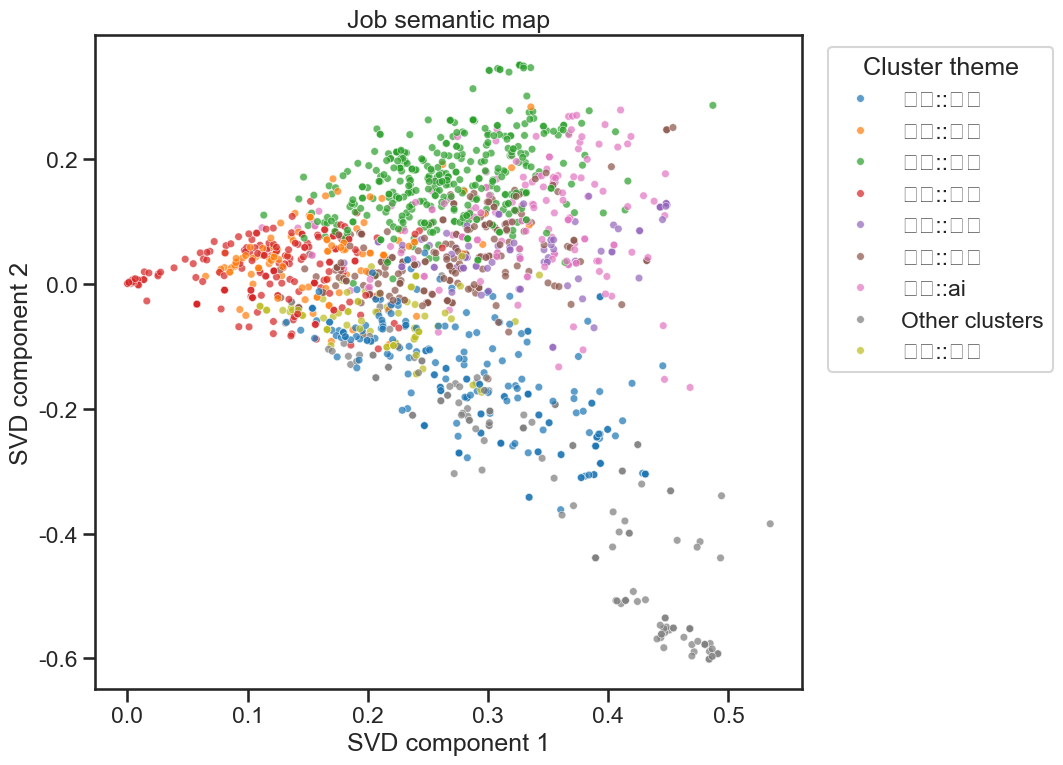

图表输出目录: D:\ayohi\job_info_collector\data\analysis\charts
Artifacts:
{'analysis_report': 'D:\\ayohi\\job_info_collector\\data\\analysis\\analysis_report.json',
 'career_track_demand': 'D:\\ayohi\\job_info_collector\\data\\analysis\\career_track_demand.csv',
 'city_distribution': 'D:\\ayohi\\job_info_collector\\data\\analysis\\city_distribution.csv',
 'city_opportunity': 'D:\\ayohi\\job_info_collector\\data\\analysis\\city_opportunity.csv',
 'company_distribution': 'D:\\ayohi\\job_info_collector\\data\\analysis\\company_distribution.csv',
 'job_category_distribution': 'D:\\ayohi\\job_info_collector\\data\\analysis\\job_category_distribution.csv',
 'ml_cluster_summary': 'D:\\ayohi\\job_info_collector\\data\\analysis\\ml_cluster_summary.csv',
 'ml_embeddings_2d': 'D:\\ayohi\\job_info_collector\\data\\analysis\\ml_embeddings_2d.csv',
 'ml_topic_summary': 'D:\\ayohi\\job_info_collector\\data\\analysis\\ml_topic_summary.csv',
 'skill_keyword_hits': 'D:\\ayohi\\job_info_collector\\data\\analys

In [18]:
charts_dir = output_dir / "charts"
charts_dir.mkdir(parents=True, exist_ok=True)

company_df = pd.DataFrame(report_adv["overview"]["by_company"])
if not company_df.empty:
    plt.figure(figsize=(9, 5.5))
    sns.barplot(data=company_df, x="name", y="count", hue="name", palette="crest", legend=False)
    plt.title("Company-level demand")
    plt.xlabel("Company")
    plt.ylabel("Job count")
    plt.xticks(rotation=20)
    plt.tight_layout()
    company_chart = charts_dir / "company_distribution.png"
    plt.savefig(company_chart, dpi=180)
    plt.show()
else:
    company_chart = None

cluster_chart = charts_dir / "cluster_distribution.png"
if not cluster_df.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=cluster_df, y="cluster_name", x="size", hue="cluster_name", palette="viridis", legend=False)
    plt.title("Cluster demand (interpretable labels)")
    plt.xlabel("Job count")
    plt.ylabel("Cluster meaning")
    plt.tight_layout()
    plt.savefig(cluster_chart, dpi=180)
    plt.show()

embedding_chart = charts_dir / "embedding_scatter.png"
if not embed_df.empty:
    sample_n = min(1600, len(embed_df))
    plot_df = embed_df.sample(sample_n, random_state=42)
    top_clusters = plot_df["cluster_name"].value_counts().head(8).index.tolist()
    plot_df["cluster_group"] = plot_df["cluster_name"].where(plot_df["cluster_name"].isin(top_clusters), "Other clusters")

    plt.figure(figsize=(11, 8))
    sns.scatterplot(data=plot_df, x="x", y="y", hue="cluster_group", alpha=0.72, s=30, palette="tab10")
    plt.title("Job semantic map")
    plt.xlabel("SVD component 1")
    plt.ylabel("SVD component 2")
    plt.legend(title="Cluster theme", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(embedding_chart, dpi=180)
    plt.show()

print("图表输出目录:", charts_dir)
print("Artifacts:")
pprint(payload_adv.get("artifacts", {}))

career = report_adv.get("career_guidance", {})
print("\nActionable suggestions:")
for idx, tip in enumerate(career.get("actionable_suggestions", []), 1):
    print(f"{idx}. {tip}")

## 求职指导与规划分析

该部分关注“怎么投、投哪里、先准备什么”，核心来自 `report_adv["career_guidance"]`：
- `career_track_demand`: 各职业赛道需求规模
- `internship_ratio_by_track`: 各赛道实习切入难易度
- `city_opportunity`: 城市机会指数（岗位量 + 赛道多样性）
- `company_track_focus`: 公司主招赛道

,track,count,share
0,backend,1020,0.2823
1,algorithm_ai,754,0.2087
2,data,675,0.1868
3,product_ops,581,0.1608
4,frontend,189,0.0523
5,design,149,0.0412
6,技术,49,0.0136
7,infra_hardware,43,0.0119
8,security,38,0.0105
9,人力,28,0.0077


C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\31742900.py:15: UserWarning: Glyph 25216 (\N{CJK UNIFIED IDEOGRAPH-6280}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\31742900.py:15: UserWarning: Glyph 26415 (\N{CJK UNIFIED IDEOGRAPH-672F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\31742900.py:15: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\31742900.py:15: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\yohi.zhong\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25216 (\N{CJK UNIFIED IDEOGRAPH-6280}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yohi.zhong\AppData\Local\Programs\Python\

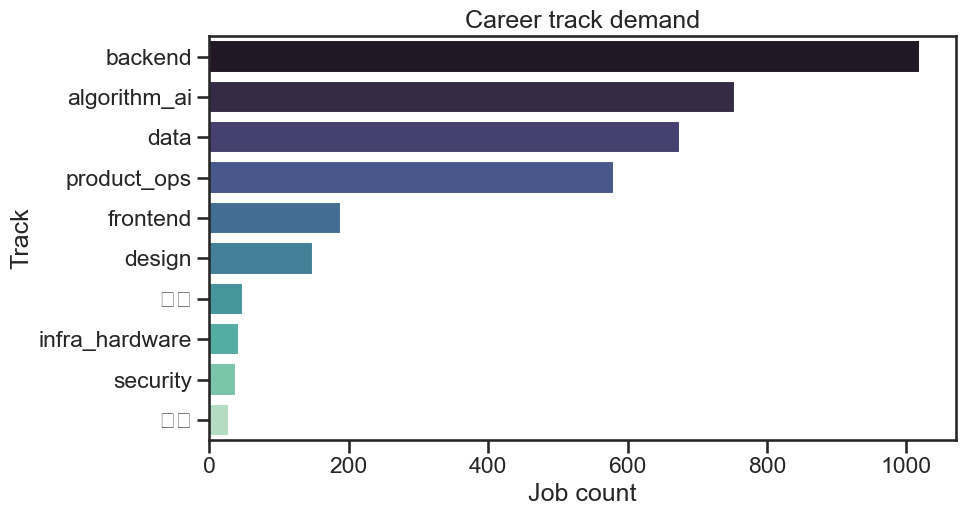

,track,internship_ratio,total
0,backend,0.9676,1020
1,algorithm_ai,0.9748,754
2,data,0.9556,675
3,product_ops,0.9552,581
4,frontend,0.9630,189
5,design,0.7651,149
6,技术,0.7143,49
7,infra_hardware,0.9535,43
8,security,0.9737,38
9,人力,1.0000,28


C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\31742900.py:26: UserWarning: Glyph 25216 (\N{CJK UNIFIED IDEOGRAPH-6280}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\31742900.py:26: UserWarning: Glyph 26415 (\N{CJK UNIFIED IDEOGRAPH-672F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\31742900.py:26: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\31742900.py:26: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\yohi.zhong\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25216 (\N{CJK UNIFIED IDEOGRAPH-6280}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yohi.zhong\AppData\Local\Programs\Python\

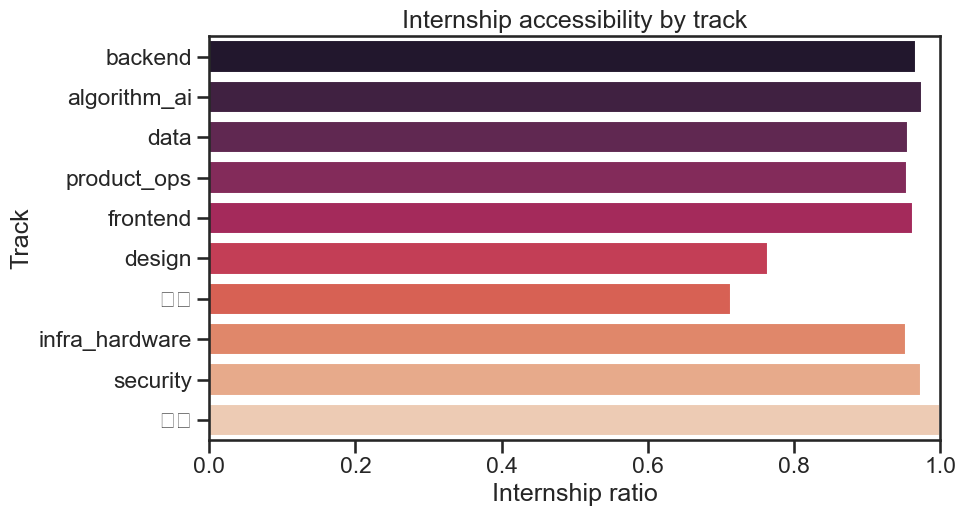

,city,job_count,track_diversity,opportunity_score
0,北京,1286,12,3137.84
1,上海,906,11,2101.92
2,深圳,614,13,1571.84
3,杭州,417,9,867.36
4,广州,178,14,477.04
5,成都,48,7,88.32
6,Unknown,30,9,62.40
7,Singapore-CapitaSky,36,5,57.60
8,Japan-Tokyo-Business,11,6,18.92
9,US-California-Palo,11,5,17.60


C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\31742900.py:36: UserWarning: Glyph 21271 (\N{CJK UNIFIED IDEOGRAPH-5317}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\31742900.py:36: UserWarning: Glyph 20140 (\N{CJK UNIFIED IDEOGRAPH-4EAC}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\31742900.py:36: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\31742900.py:36: UserWarning: Glyph 28023 (\N{CJK UNIFIED IDEOGRAPH-6D77}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\31742900.py:36: UserWarning: Glyph 28145 (\N{CJK UNIFIED IDEOGRAPH-6DF1}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yohi.zhong\AppData\Local\Temp\ipykernel_22200\31742900.py:36: UserWarning: Glyph 22323 (\N{CJK UNIFIE

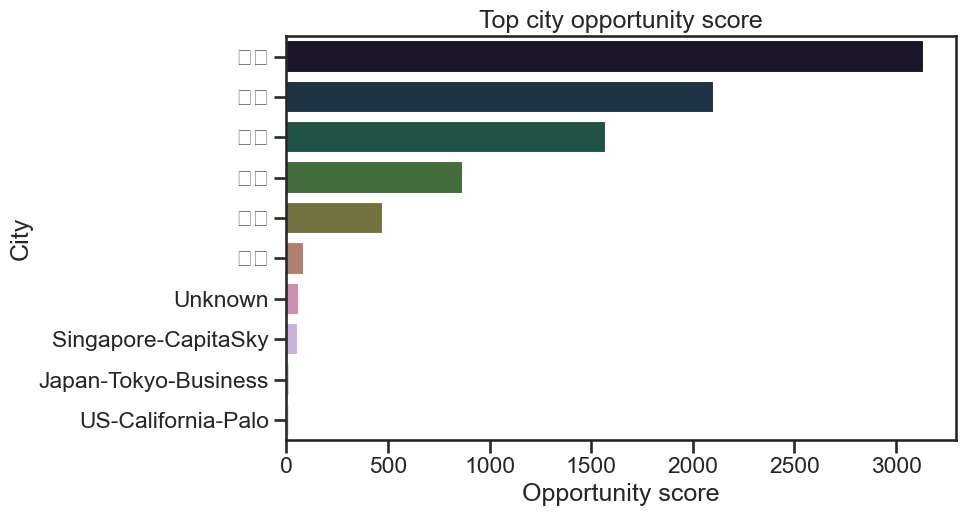

,company,total_jobs,primary_track,primary_track_share
0,字节跳动,2992,backend,0.3102
1,腾讯,390,backend,0.1821
2,阿里巴巴(蚂蚁集团),90,algorithm_ai,0.6222
3,库洛游戏,81,design,0.3333
4,网易互娱,60,design,0.3000



求职行动建议：
1. backend 方向岗位需求高且实习占比高，建议优先通过实习路径切入。
2. algorithm_ai 方向岗位需求高且实习占比高，建议优先通过实习路径切入。
3. data 方向岗位需求高且实习占比高，建议优先通过实习路径切入。
4. 地域选择上，北京 的综合机会指数最高，可作为优先投递城市。


In [19]:
career = report_adv.get("career_guidance", {})

track_df = pd.DataFrame(career.get("career_track_demand", []))
intern_df = pd.DataFrame(career.get("internship_ratio_by_track", []))
city_df = pd.DataFrame(career.get("city_opportunity", []))
company_focus_df = pd.DataFrame(career.get("company_track_focus", []))

if not track_df.empty:
    display(track_df)
    plt.figure(figsize=(10, 5.5))
    sns.barplot(data=track_df, y="track", x="count", hue="track", palette="mako", legend=False)
    plt.title("Career track demand")
    plt.xlabel("Job count")
    plt.ylabel("Track")
    plt.tight_layout()
    plt.show()

if not intern_df.empty:
    display(intern_df)
    plt.figure(figsize=(10, 5.5))
    sns.barplot(data=intern_df, y="track", x="internship_ratio", hue="track", palette="rocket", legend=False)
    plt.title("Internship accessibility by track")
    plt.xlabel("Internship ratio")
    plt.ylabel("Track")
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()

if not city_df.empty:
    display(city_df.head(10))
    plt.figure(figsize=(10, 5.5))
    sns.barplot(data=city_df.head(10), y="city", x="opportunity_score", hue="city", palette="cubehelix", legend=False)
    plt.title("Top city opportunity score")
    plt.xlabel("Opportunity score")
    plt.ylabel("City")
    plt.tight_layout()
    plt.show()

if not company_focus_df.empty:
    display(company_focus_df.head(10))

print("\n求职行动建议：")
for idx, tip in enumerate(career.get("actionable_suggestions", []), 1):
    print(f"{idx}. {tip}")